# Task 2: Customer Segmentation Using K-Means Clustering

## Problem Statement

Businesses can improve their marketing strategies by grouping customers with similar purchasing behavior.

## Objective

The objective of this project is to segment customers using K-Means Clustering based on their demographic and spending characteristics. The identified customer groups can help businesses design targeted marketing strategies.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use("ggplot")

## Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Data Cleaning

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (200, 5)


## Exploratory Data Analysis (EDA)

In [10]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


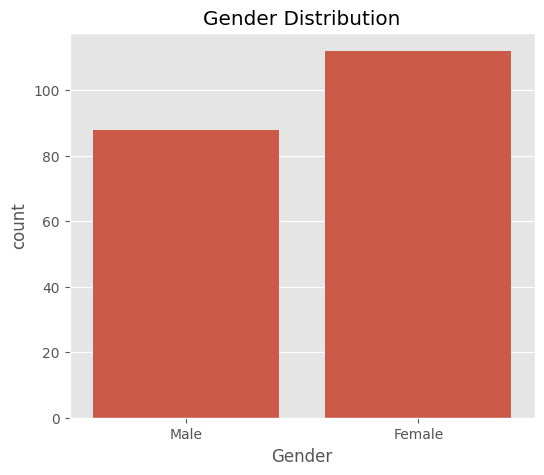

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

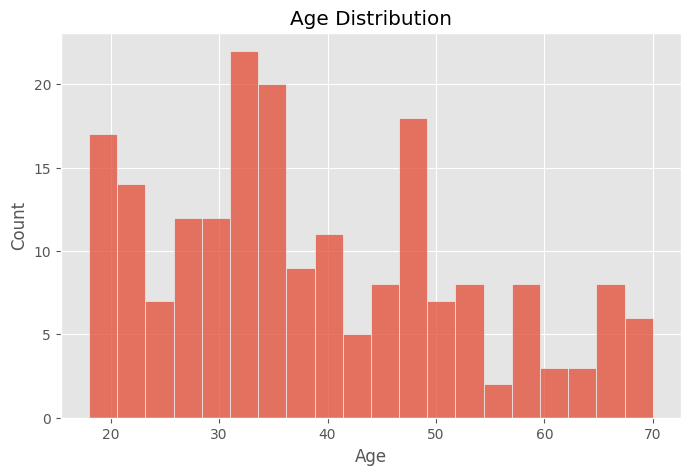

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

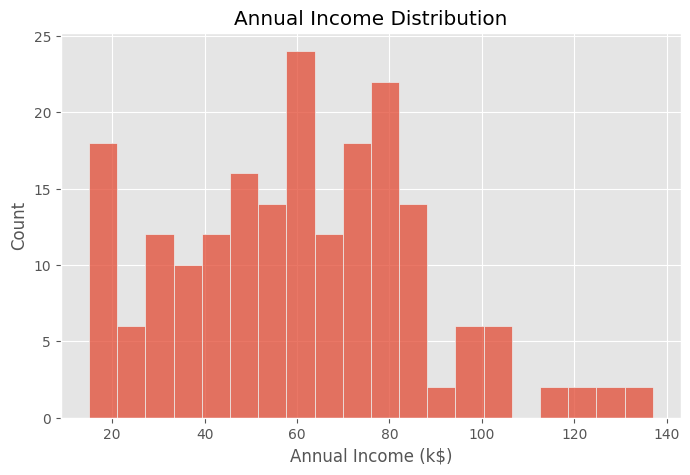

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title("Annual Income Distribution")

plt.show()

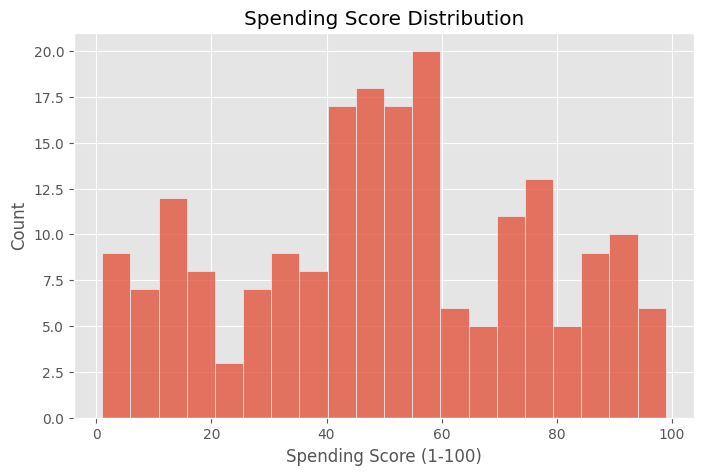

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title("Spending Score Distribution")

plt.show()

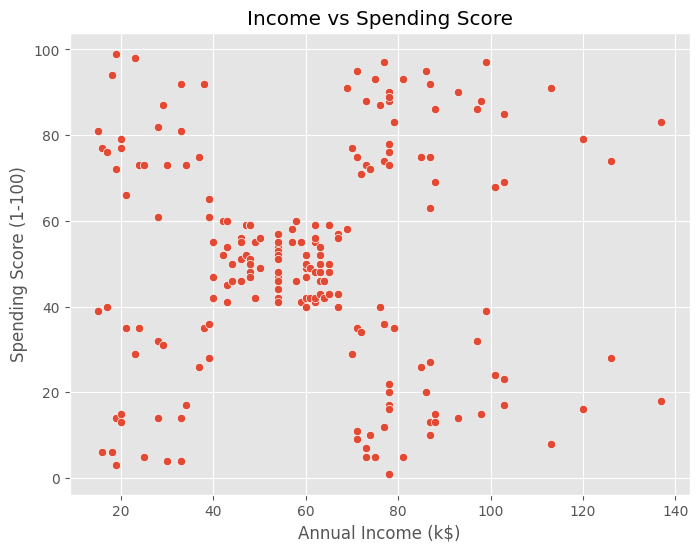

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")

plt.show()

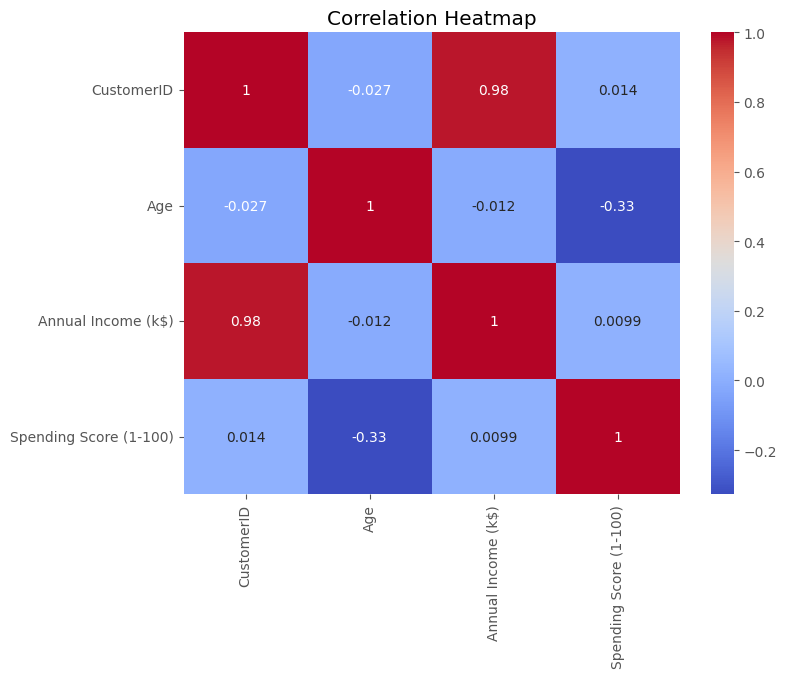

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Feature Selection

In [17]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

## Finding the Optimal Number of Clusters (Elbow Method)

In [19]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

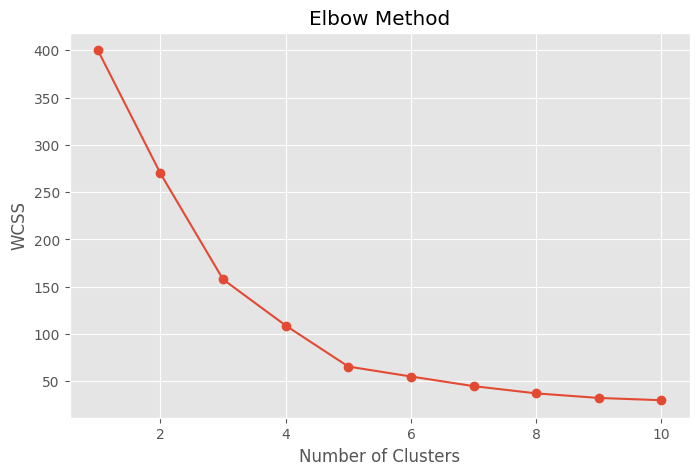

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

## K-Means Clustering

In [21]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segments

In [22]:
df["Cluster"].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


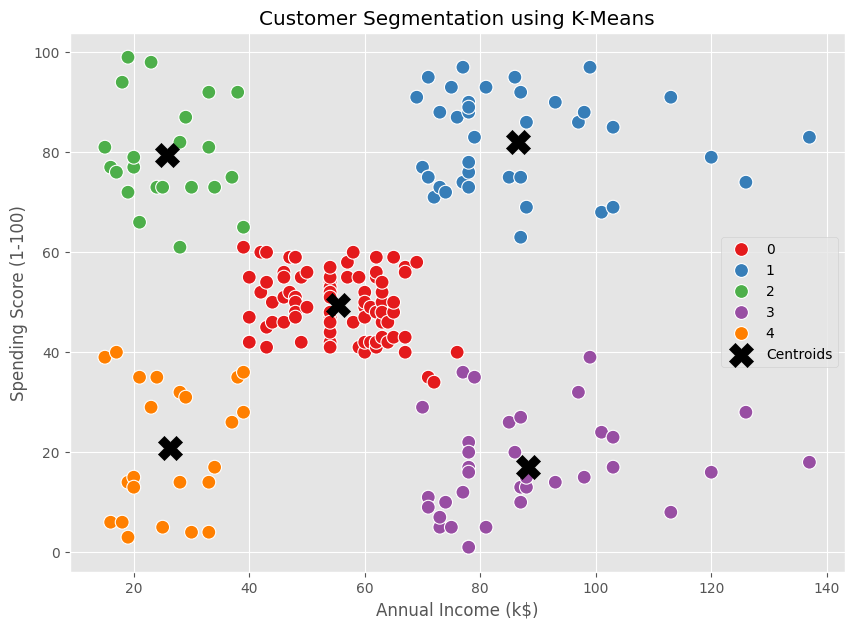

In [23]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=100
)

plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    c="black",
    marker="X",
    s=300,
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

## PCA Visualization

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

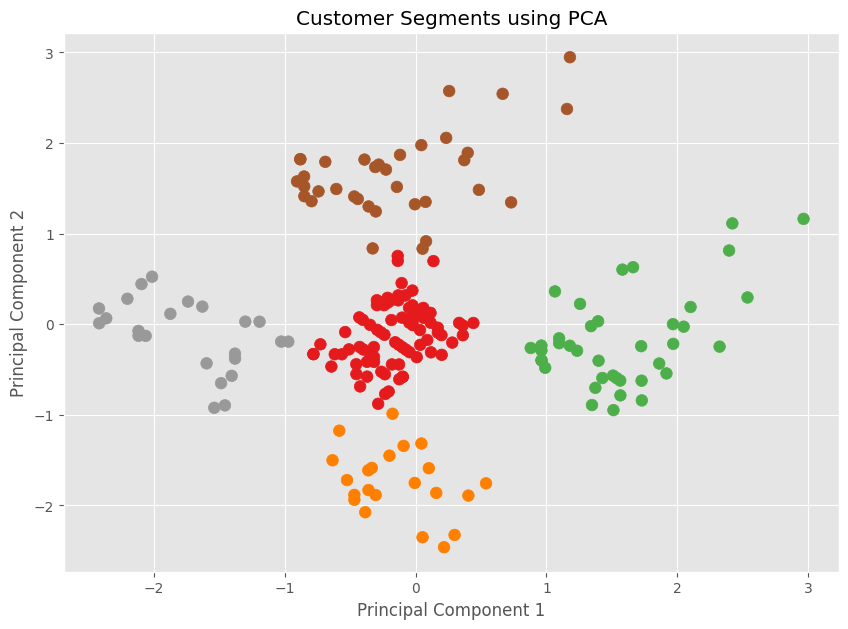

In [25]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="Set1",
    s=70
)

plt.title("Customer Segments using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

## Marketing Strategies

In [26]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)", "Spending Score (1-100)", "Age"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


### Suggested Marketing Strategies

**Cluster 0**
- Customers with moderate income and spending.
- Offer seasonal discounts and loyalty rewards.

**Cluster 1**
- High income and high spending customers.
- Promote premium products and exclusive memberships.

**Cluster 2**
- Low income and low spending customers.
- Focus on budget-friendly products and discount offers.

**Cluster 3**
- High income but low spending customers.
- Encourage purchases using personalized promotions and special offers.

**Cluster 4**
- Low income but high spending customers.
- Recommend affordable products with bundle deals to increase customer satisfaction.

# Conclusion

In this project, the Mall Customers dataset was analyzed to identify different customer groups using K-Means Clustering. After performing exploratory data analysis and feature scaling, the Elbow Method indicated that **5 clusters** were the optimal choice.

Principal Component Analysis (PCA) was used to visualize the customer segments in two dimensions. The resulting clusters revealed distinct customer behaviors based on annual income and spending score.

Finally, suitable marketing strategies were proposed for each customer segment. These insights can help businesses design targeted marketing campaigns, improve customer engagement, and increase sales through personalized offers.